# 5 UE / 3 gNB Radio Mobility Trace - 1 Minute

This notebook runs five eMBB UEs moving in different directions across a 3-gNB topology for one simulated minute.

It records one row per `(tick, UE)` with the radio and scheduler metrics: serving gNB, SINR, SNR, RSRP, RSSI, RSRQ, MCS, spectral efficiency, RX probability, allocated/used/wasted PRBs, queue, throughput, and per-gNB RSRP/SINR/RSRQ.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scenario_creator import create_nodeb
from multi_gnb_wrapper import MultiGNBWrapper

pd.set_option("display.max_columns", 160)

## Simulation Settings

The default tick is 10 ms so the full 1-minute, 5-UE trace runs quickly in a notebook. Set `STEP_DT = 1e-3` for a dense 1 ms trace if you need it.

In [2]:
SEED = 7
STEP_DT = 1e-2
SIM_SECONDS = 120.0
LOG_EVERY = 1
PLOT_EVERY = 10

A3_HYSTERESIS_DB = 1.0
A3_TTT_STEPS = 3

RESULT_DIR = ROOT / "results" / "five_ue_3gnb_1min_radio_mobility_trace"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
TRACE_CSV = RESULT_DIR / "five_ue_radio_trace.csv"
HO_CSV = RESULT_DIR / "handover_events.csv"

N_STEPS = int(round(SIM_SECONDS / STEP_DT))
N_STEPS

12000

## Topology And UE Mobility

The five UEs start in different places and move in different directions. Speeds are moderate so the 60 s trace shows radio evolution without hitting world-bound bounces too often.

In [3]:
GNB_SPECS = [
    {"id": 0, "x": 0.0, "y": 0.0, "carrier_id": 0},
    {"id": 1, "x": 600.0, "y": 0.0, "carrier_id": 0},
    {"id": 2, "x": 300.0, "y": 520.0, "carrier_id": 0},
]

UE_SPECS = [
    {"name": "ue0_east", "x": 80.0, "y": 80.0, "vx": 4.0, "vy": 1.0, "bit_rate": 1_200_000.0},
    {"name": "ue1_west", "x": 520.0, "y": 70.0, "vx": -3.5, "vy": 1.5, "bit_rate": 1_800_000.0},
    {"name": "ue2_south", "x": 300.0, "y": 455.0, "vx": 0.0, "vy": -4.0, "bit_rate": 900_000.0},
    {"name": "ue3_diag", "x": 160.0, "y": 260.0, "vx": 3.0, "vy": -2.5, "bit_rate": 1_500_000.0},
    {"name": "ue4_sw", "x": 470.0, "y": 330.0, "vx": -3.0, "vy": -3.0, "bit_rate": 700_000.0},
]

def make_gnbs(seed=SEED):
    rng = np.random.default_rng(seed)
    gnbs = []
    for spec in GNB_SPECS:
        gnbs.append(
            create_nodeb(
                rng,
                0,
                slots_per_step=1,
                L1_level=False,
                node_id=spec["id"],
                node_x=spec["x"],
                node_y=spec["y"],
                coverage_radius=760,
                n_prbs_override=100,
                wrapper_managed_mobile_slices=True,
                carrier_id=spec["carrier_id"],
            )
        )
    return gnbs


def make_env():
    gnbs = make_gnbs()
    env = MultiGNBWrapper(
        gnbs,
        step_dt=STEP_DT,
        mobility_dt=STEP_DT,
        radio_substeps=1,
        max_episode_steps=N_STEPS,
        handover_ttt=A3_TTT_STEPS,
        a3_hysteresis_db=A3_HYSTERESIS_DB,
        disconnect_sinr_db=-100.0,
        ue_traffic_profiles={
            "eMBB": {
                "traffic_model": "fixed_packet_cbr",
                "packet_size_bits": 3000.0,
                "bit_rate": 1_000_000.0,
            }
        },
    )
    ue_ids = []
    ue_names = {}
    for spec in UE_SPECS:
        ue_id = env.add_ue(
            x=spec["x"],
            y=spec["y"],
            vx=spec["vx"],
            vy=spec["vy"],
            slice_type="eMBB",
            bit_rate=spec["bit_rate"],
            packet_size_bits=3000.0,
            traffic_model="fixed_packet_cbr",
        )
        ue_ids.append(ue_id)
        ue_names[ue_id] = spec["name"]
    return env, gnbs, ue_ids, ue_names


env, gnbs, ue_ids, ue_names = make_env()
[(ue_id, ue_names[ue_id], env.get_ue(ue_id).serving_gnb) for ue_id in ue_ids]

[(0, 'ue0_east', 0),
 (1, 'ue1_west', 1),
 (2, 'ue2_south', 2),
 (3, 'ue3_diag', 2),
 (4, 'ue4_sw', 2)]

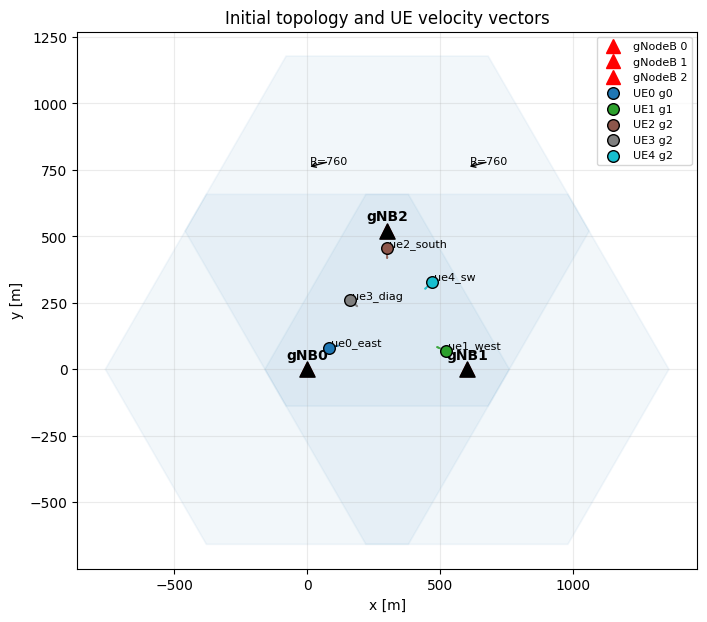

In [4]:
def plot_topology_snapshot(env, gnbs, ue_ids, title):
    fig, ax = plt.subplots(figsize=(8, 7))
    for gnb in gnbs:
        gnb.visualize_coverage(ax=ax, color="tab:blue", alpha=0.055, edge_color="tab:blue", linewidth=1.2)
        ax.scatter([gnb.x], [gnb.y], marker="^", s=120, c="black", zorder=6)
        ax.text(gnb.x, gnb.y + 28, f"gNB{gnb.id}", ha="center", va="bottom", fontsize=10, weight="bold")

    colors = plt.cm.tab10(np.linspace(0, 1, len(ue_ids)))
    for color, ue_id in zip(colors, ue_ids):
        ue = env.get_ue(ue_id)
        ax.scatter([ue.x], [ue.y], s=70, color=color, edgecolor="black", zorder=8, label=f"UE{ue_id} g{ue.serving_gnb}")
        ax.arrow(ue.x, ue.y, ue.vx * 8.0, ue.vy * 8.0, color=color, width=1.5, alpha=0.8)
        ax.text(ue.x + 8, ue.y + 8, ue_names[ue_id], fontsize=8)

    ax.set_title(title)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.grid(True, alpha=0.25)
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="upper right", fontsize=8)
    plt.show()


plot_topology_snapshot(env, gnbs, ue_ids, "Initial topology and UE velocity vectors")

## Run Simulation And Save Trace

In [5]:
rows = []

for step in range(N_STEPS):
    _obs, _reward, terminated, truncated, _info = env.step(0)
    if step % LOG_EVERY == 0 or terminated or truncated:
        time_s = float(env._step_count * STEP_DT)
        for ue_id in ue_ids:
            ue = env.get_ue(ue_id)
            radio = env.get_ue_radio_metrics(ue_id)
            row = {
                "tick": int(env._step_count),
                "time_s": time_s,
                "time_ms": time_s * 1000.0,
                "ue_id": int(ue_id),
                "ue_name": ue_names[ue_id],
                "slice_type": getattr(ue, "slice_type", "eMBB"),
                "x": float(ue.x),
                "y": float(ue.y),
                "vx": float(ue.vx),
                "vy": float(ue.vy),
                "serving_gnb": radio["serving_gnb"],
                "connected": bool(radio["connected"]),
                "sinr_db": float(radio["sinr_db"]),
                "scheduled_sinr_db": float(radio["scheduled_sinr_db"]),
                "snr_db": float(radio["snr_db"]),
                "rsrp_dbm": float(radio["rsrp_dbm"]),
                "rssi_dbm": float(radio["rssi_dbm"]),
                "rsrq_db": float(radio["rsrq_db"]),
                "rx_power_dbm": float(radio["rx_power_dbm"]),
                "interference_dbm": float(radio["interference_dbm"]),
                "noise_dbm": float(radio["noise_dbm"]),
                "mcs": int(radio["mcs"]),
                "spectral_efficiency": float(radio["spectral_efficiency"]),
                "rx_probability": float(radio["rx_probability"]),
                "allocated_prbs": int(radio["allocated_prbs"]),
                "used_prbs": int(radio["used_prbs"]),
                "useful_prbs": int(radio["useful_prbs"]),
                "wasted_prbs": int(radio["wasted_prbs"]),
                "new_bits": float(radio["new_bits"]),
                "scheduled_bits": float(radio["scheduled_bits"]),
                "served_bits": float(radio["served_bits"]),
                "queue_bits": float(radio["queue"]),
                "throughput_bps": float(radio["throughput"]),
                "target_gnb": radio["target_gnb"],
                "ho_pending": bool(radio["ho_pending"]),
                "environment_loss_db": float(radio["environment_loss_db"]),
            }
            for gnb in gnbs:
                link = env._compute_link_metrics(gnb, ue)
                row[f"g{gnb.id}_sinr_db"] = float(link["sinr_db"])
                row[f"g{gnb.id}_rsrp_dbm"] = float(link["rsrp_dbm"])
                row[f"g{gnb.id}_rsrq_db"] = float(link["rsrq_db"])
            rows.append(row)
    if terminated or truncated:
        break

trace = pd.DataFrame(rows)
trace.to_csv(TRACE_CSV, index=False)

handover_events = pd.DataFrame(env.get_handover_events())
if not handover_events.empty:
    handover_events["time_s"] = handover_events["step"] * STEP_DT
handover_events.to_csv(HO_CSV, index=False)

TRACE_CSV, trace.shape, HO_CSV, handover_events.shape

(PosixPath('/home/oussama/Desktop/chech/results/five_ue_3gnb_1min_radio_mobility_trace/five_ue_radio_trace.csv'),
 (60000, 45),
 PosixPath('/home/oussama/Desktop/chech/results/five_ue_3gnb_1min_radio_mobility_trace/handover_events.csv'),
 (6, 10))

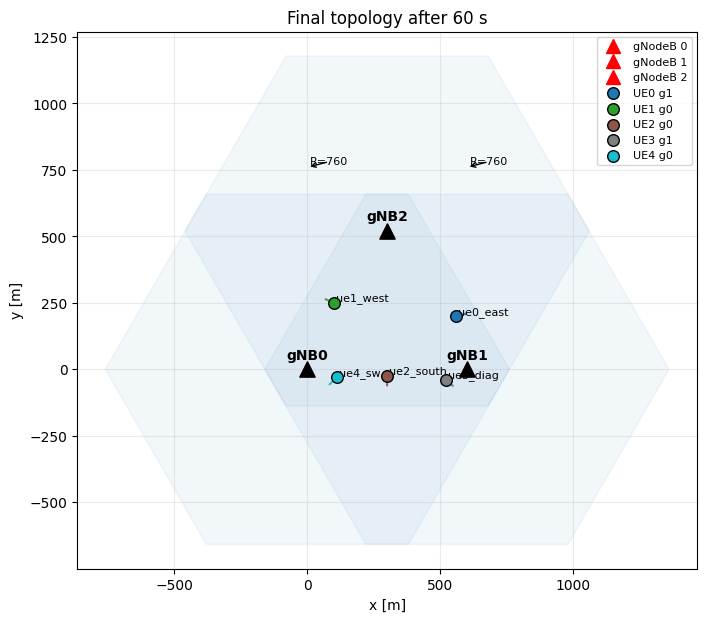

In [6]:
plot_topology_snapshot(env, gnbs, ue_ids, "Final topology after 60 s")

## Summary Tables

In [7]:
summary = (
    trace.groupby(["ue_id", "ue_name"])
    .agg(
        samples=("tick", "count"),
        first_serving=("serving_gnb", "first"),
        final_serving=("serving_gnb", "last"),
        mean_sinr_db=("sinr_db", "mean"),
        min_sinr_db=("sinr_db", "min"),
        max_sinr_db=("sinr_db", "max"),
        mean_rsrp_dbm=("rsrp_dbm", "mean"),
        mean_rsrq_db=("rsrq_db", "mean"),
        mean_rx_probability=("rx_probability", "mean"),
        mean_mcs=("mcs", "mean"),
        mean_allocated_prbs=("allocated_prbs", "mean"),
        mean_used_prbs=("used_prbs", "mean"),
        mean_wasted_prbs=("wasted_prbs", "mean"),
        final_queue_bits=("queue_bits", "last"),
        mean_throughput_bps=("throughput_bps", "mean"),
    )
    .reset_index()
)

serving_changes = (
    trace.sort_values(["ue_id", "tick"])
    .groupby("ue_id")["serving_gnb"]
    .apply(lambda s: int((s.diff().fillna(0) != 0).sum()))
    .rename("handover_count")
    .reset_index()
)
summary = summary.merge(serving_changes, on="ue_id", how="left")
summary

,ue_id,ue_name,samples,first_serving,final_serving,mean_sinr_db,min_sinr_db,max_sinr_db,mean_rsrp_dbm,mean_rsrq_db,mean_rx_probability,mean_mcs,mean_allocated_prbs,mean_used_prbs,mean_wasted_prbs,final_queue_bits,mean_throughput_bps,handover_count
0,0,ue0_east,12000,0,1,6.752693,-2.805061,21.485681,-78.841280,18.706959,0.818388,6.206417,57.928667,44.699917,13.228750,42508684.0,8.403641e+05,1
1,1,ue1_west,12000,1,0,4.615879,-3.636551,22.645830,-80.179982,18.011540,0.707087,4.568250,65.374333,52.117750,13.256583,120135150.0,7.971236e+05,1
2,2,ue2_south,12000,2,0,5.741187,-4.016890,31.685914,-79.122291,17.786671,0.668409,6.456667,42.773333,42.290833,0.482500,47152644.0,5.058693e+05,1
3,3,ue3_diag,12000,2,1,6.306640,-2.726367,26.776692,-78.858358,18.006819,0.703695,6.686833,51.034500,51.034500,0.000000,45748716.0,1.105375e+06,2
4,4,ue4_sw,12000,2,0,4.989626,-3.989907,21.985541,-79.956296,18.044540,0.615185,5.166583,44.564167,44.563917,0.000250,7812994.0,6.256630e+05,1


In [8]:
handover_events

,step,ue_id,slice_type,from_gnb,to_gnb,rsrp_serving_dbm,rsrp_target_dbm,offset_db,controller,time_s
0,2273,3,EMBB,2,0,-84.600597,-83.598976,0.0,MultiGNBWrapper,22.73
1,5037,3,EMBB,0,1,-85.285217,-84.276975,0.0,MultiGNBWrapper,50.37
2,5689,4,EMBB,2,0,-86.308126,-85.300780,0.0,MultiGNBWrapper,56.89
3,5781,0,EMBB,0,1,-85.362847,-84.352322,0.0,MultiGNBWrapper,57.81
4,6634,1,EMBB,1,0,-86.060433,-85.054524,0.0,MultiGNBWrapper,66.34
5,7402,2,EMBB,2,0,-86.326650,-85.320005,0.0,MultiGNBWrapper,74.02


## UE Paths And Serving Cells

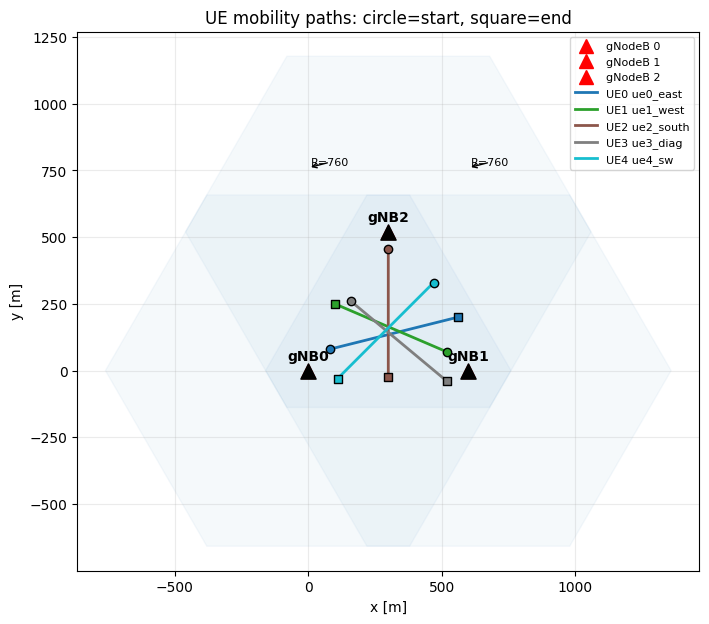

In [9]:
trace_sorted = trace.sort_values(["ue_id", "tick"])
plot_trace = pd.concat(
    [group.iloc[::PLOT_EVERY] for _ue_id, group in trace_sorted.groupby("ue_id", sort=False)],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(9, 7))
for gnb in gnbs:
    gnb.visualize_coverage(ax=ax, color="tab:blue", alpha=0.045, edge_color="tab:blue", linewidth=1.0)
    ax.scatter([gnb.x], [gnb.y], marker="^", s=120, c="black", zorder=6)
    ax.text(gnb.x, gnb.y + 28, f"gNB{gnb.id}", ha="center", va="bottom", fontsize=10, weight="bold")

colors = plt.cm.tab10(np.linspace(0, 1, len(ue_ids)))
for color, ue_id in zip(colors, ue_ids):
    sub = plot_trace[plot_trace["ue_id"] == ue_id]
    ax.plot(sub["x"], sub["y"], color=color, linewidth=2.0, label=f"UE{ue_id} {ue_names[ue_id]}")
    ax.scatter(sub["x"].iloc[0], sub["y"].iloc[0], marker="o", color=color, edgecolor="black", zorder=8)
    ax.scatter(sub["x"].iloc[-1], sub["y"].iloc[-1], marker="s", color=color, edgecolor="black", zorder=8)

ax.set_title("UE mobility paths: circle=start, square=end")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.grid(True, alpha=0.25)
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper right", fontsize=8)
plt.show()

## Radio Metric Timelines

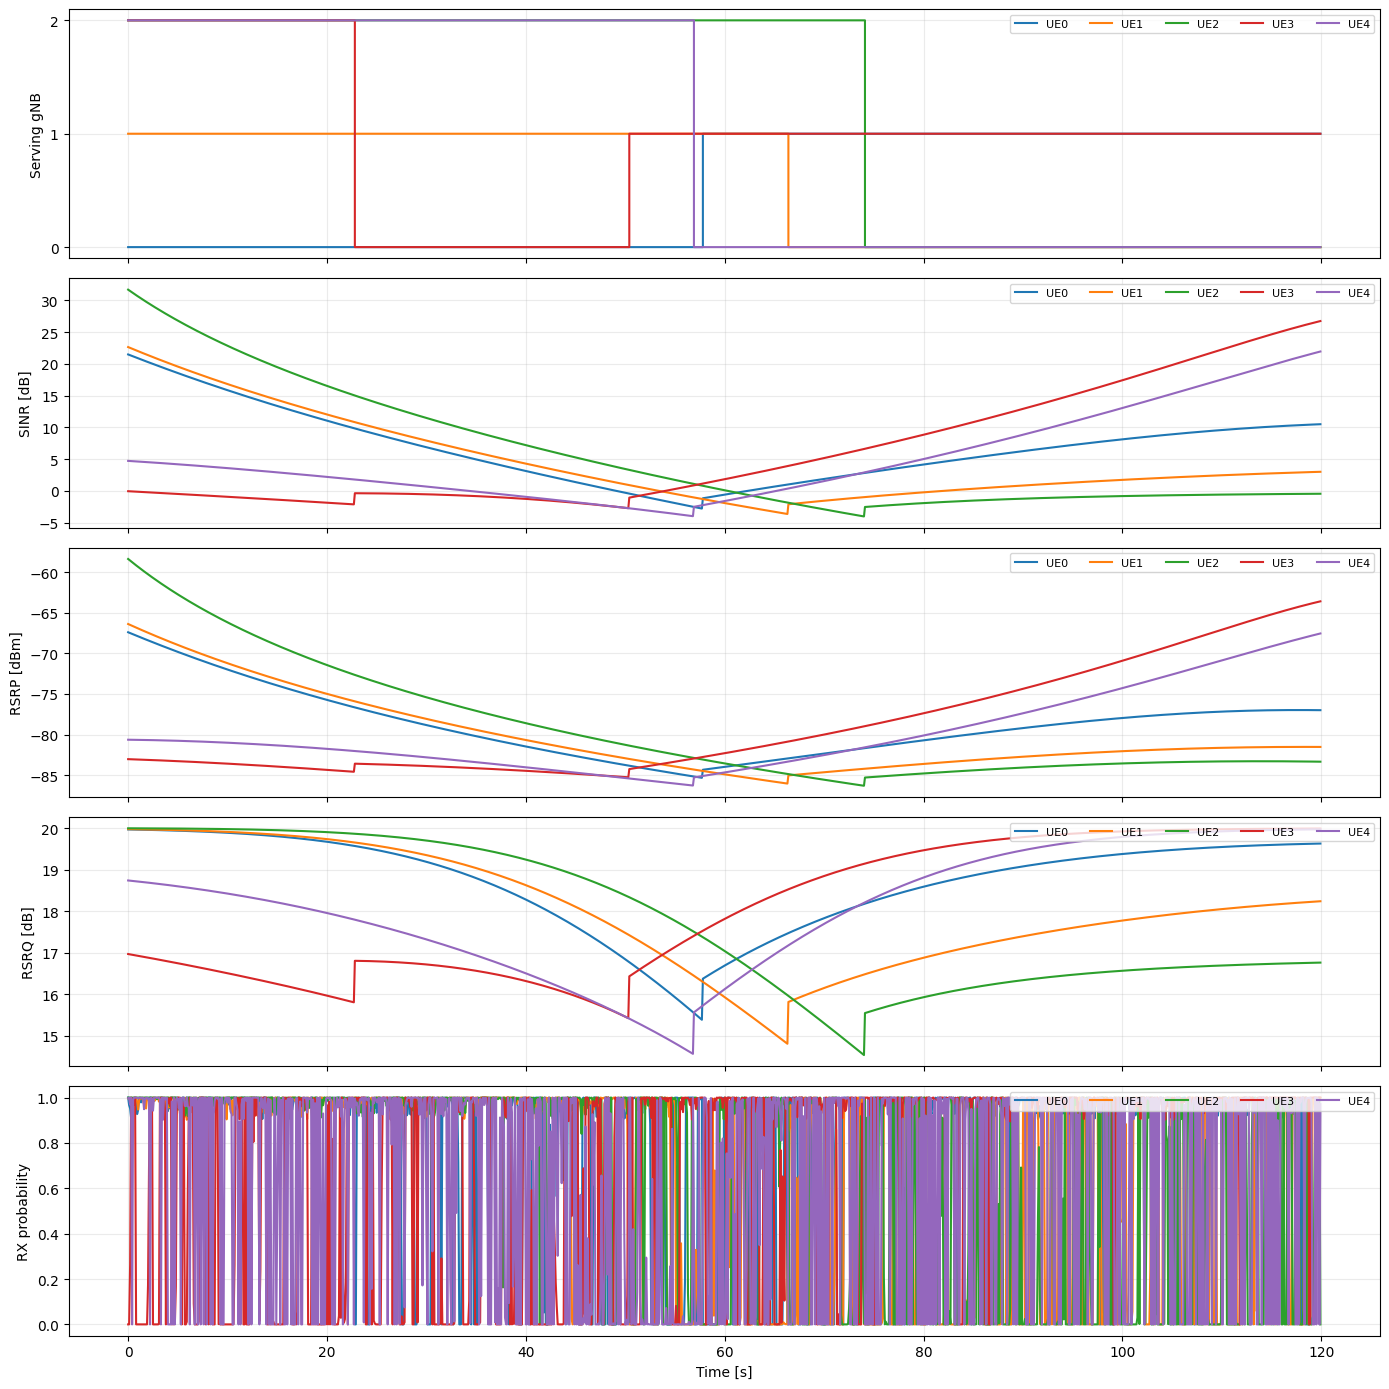

In [10]:
fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)
metric_specs = [
    ("serving_gnb", "Serving gNB"),
    ("sinr_db", "SINR [dB]"),
    ("rsrp_dbm", "RSRP [dBm]"),
    ("rsrq_db", "RSRQ [dB]"),
    ("rx_probability", "RX probability"),
]

for ax, (metric, ylabel) in zip(axes, metric_specs):
    for ue_id in ue_ids:
        sub = plot_trace[plot_trace["ue_id"] == ue_id]
        style = "steps-post" if metric == "serving_gnb" else "default"
        if style == "steps-post":
            ax.plot(sub["time_s"], sub[metric], drawstyle="steps-post", label=f"UE{ue_id}")
        else:
            ax.plot(sub["time_s"], sub[metric], label=f"UE{ue_id}")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)
    if metric == "rx_probability":
        ax.set_ylim(-0.05, 1.05)
    if metric == "serving_gnb":
        ax.set_yticks([0, 1, 2])
    ax.legend(loc="upper right", ncol=5, fontsize=8)

axes[-1].set_xlabel("Time [s]")
plt.tight_layout()
plt.show()

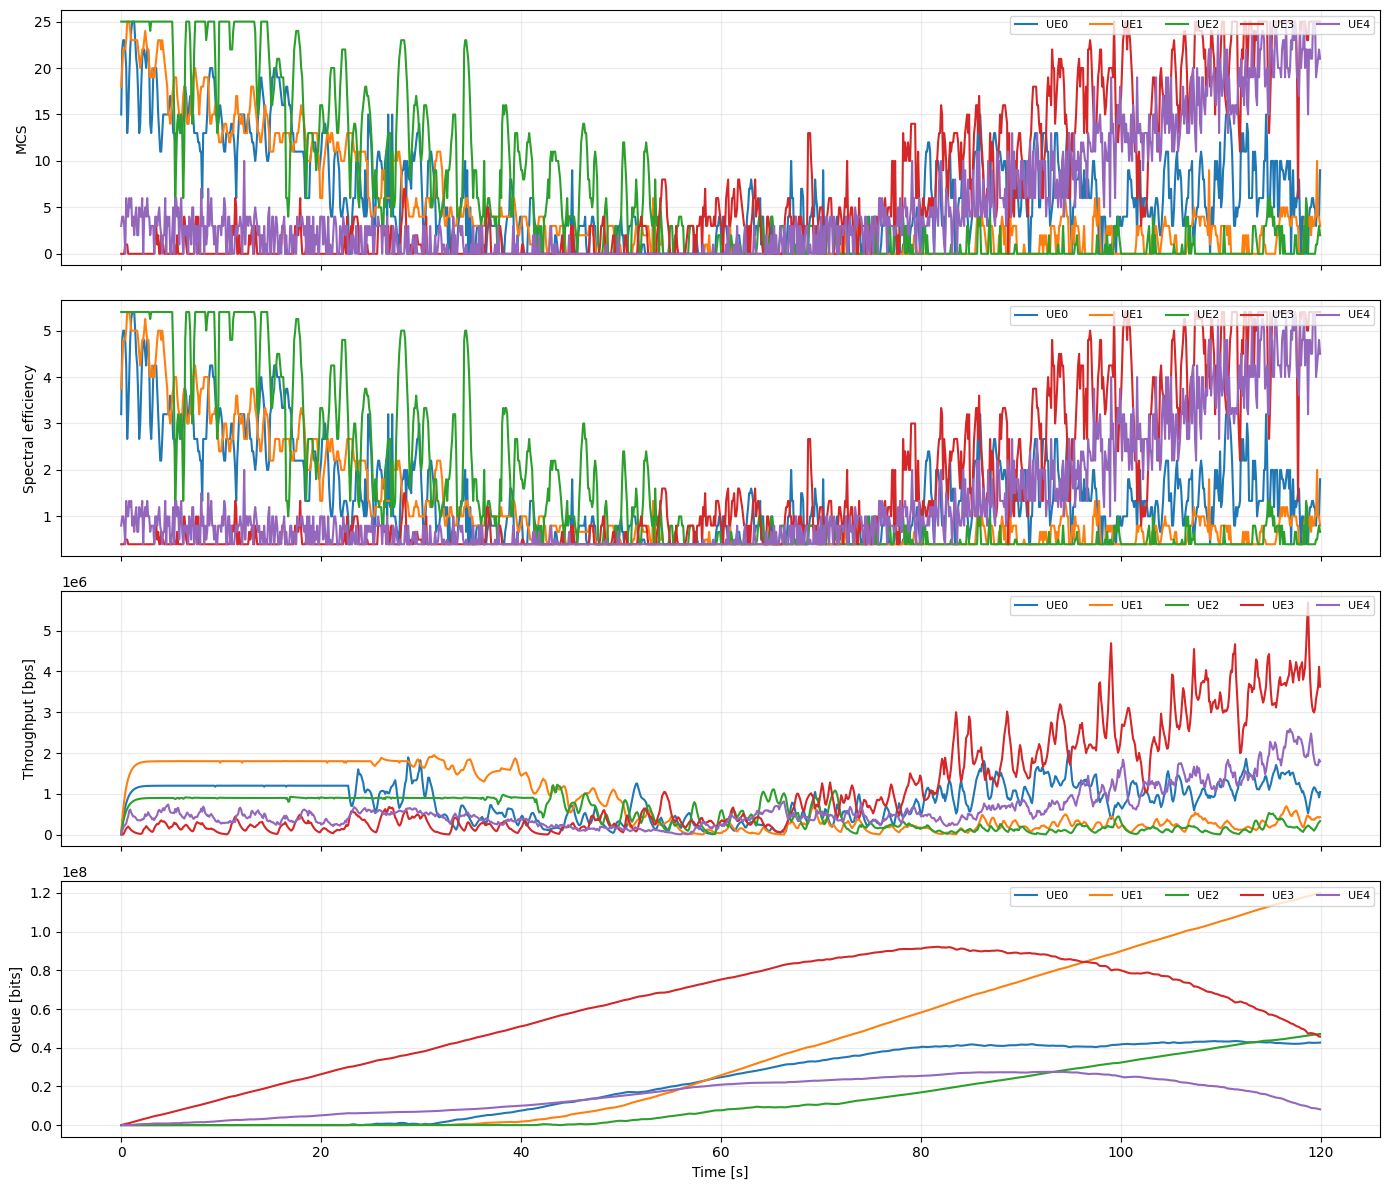

In [11]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
metric_specs = [
    ("mcs", "MCS"),
    ("spectral_efficiency", "Spectral efficiency"),
    ("throughput_bps", "Throughput [bps]"),
    ("queue_bits", "Queue [bits]"),
]

for ax, (metric, ylabel) in zip(axes, metric_specs):
    for ue_id in ue_ids:
        sub = plot_trace[plot_trace["ue_id"] == ue_id]
        ax.plot(sub["time_s"], sub[metric], label=f"UE{ue_id}")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper right", ncol=5, fontsize=8)

axes[-1].set_xlabel("Time [s]")
plt.tight_layout()
plt.show()

## PRB Accounting

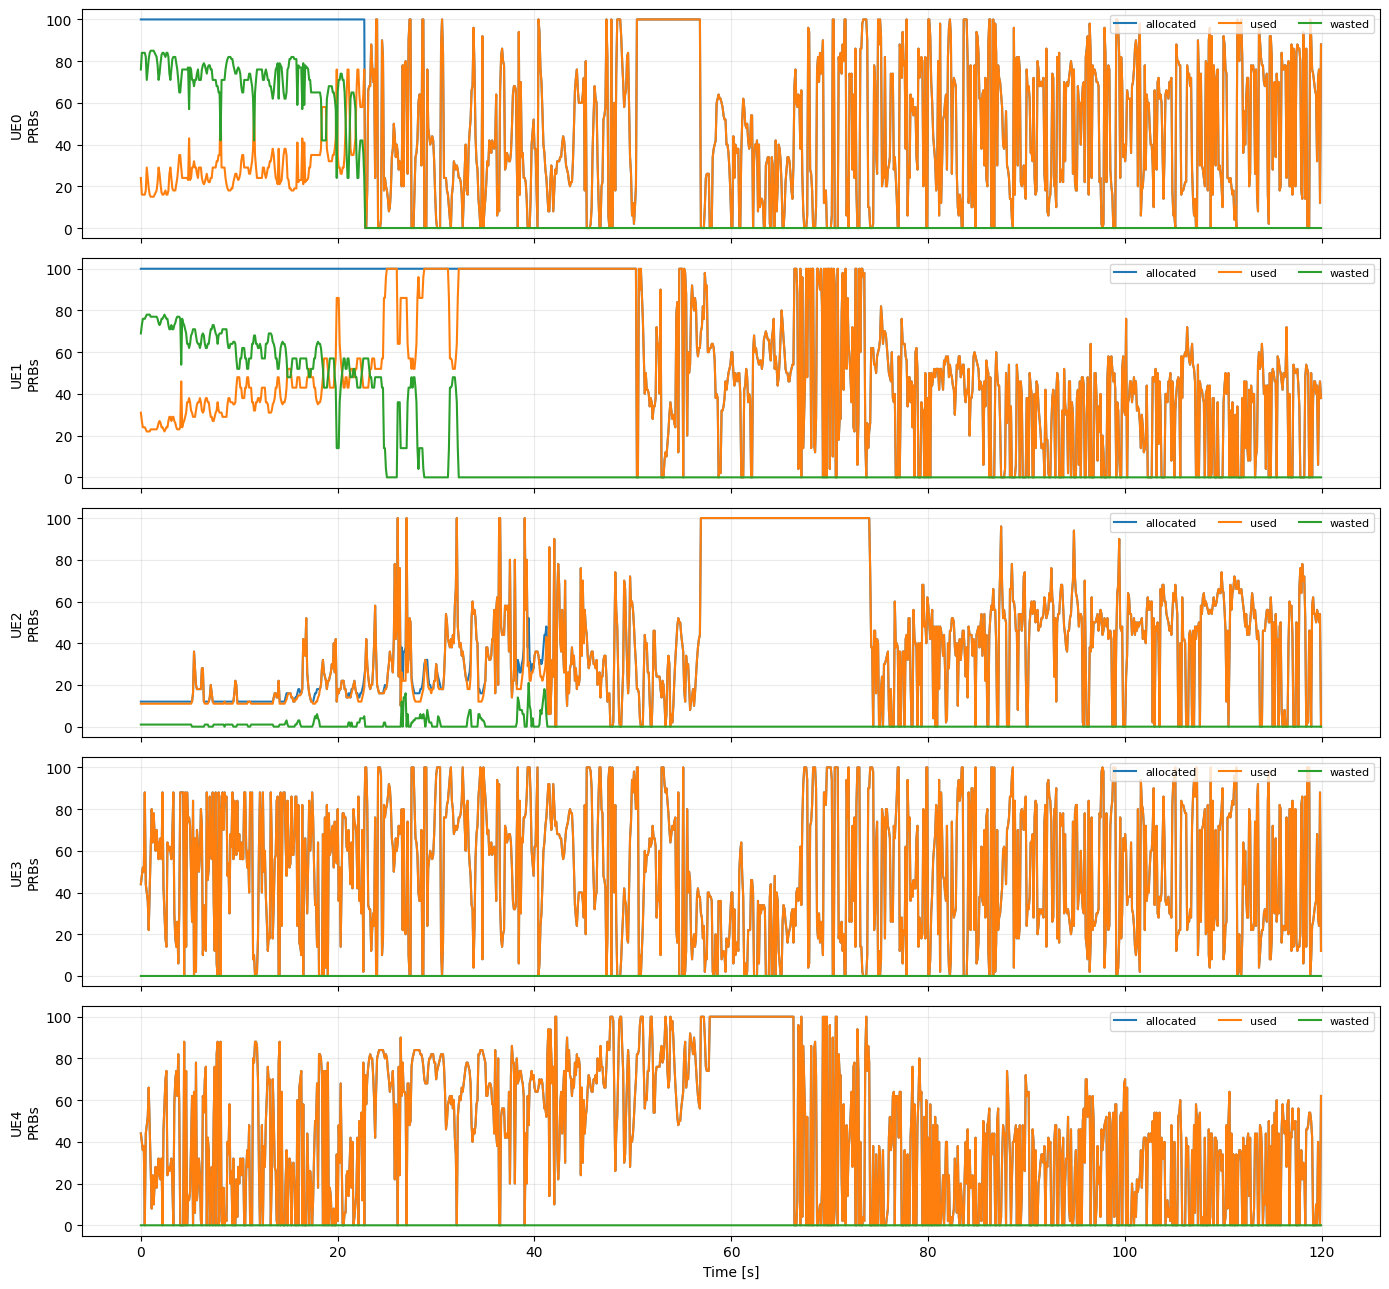

In [12]:
fig, axes = plt.subplots(len(ue_ids), 1, figsize=(14, 2.6 * len(ue_ids)), sharex=True)
for ax, ue_id in zip(axes, ue_ids):
    sub = plot_trace[plot_trace["ue_id"] == ue_id]
    ax.plot(sub["time_s"], sub["allocated_prbs"], label="allocated", color="tab:blue")
    ax.plot(sub["time_s"], sub["used_prbs"], label="used", color="tab:orange")
    ax.plot(sub["time_s"], sub["wasted_prbs"], label="wasted", color="tab:green")
    ax.set_ylabel(f"UE{ue_id}\nPRBs")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper right", ncol=3, fontsize=8)
axes[-1].set_xlabel("Time [s]")
plt.tight_layout()
plt.show()

## Per-gNB Measurements For One UE

Change `UE_TO_INSPECT` to any UE id to see how that UE measures all three cells.

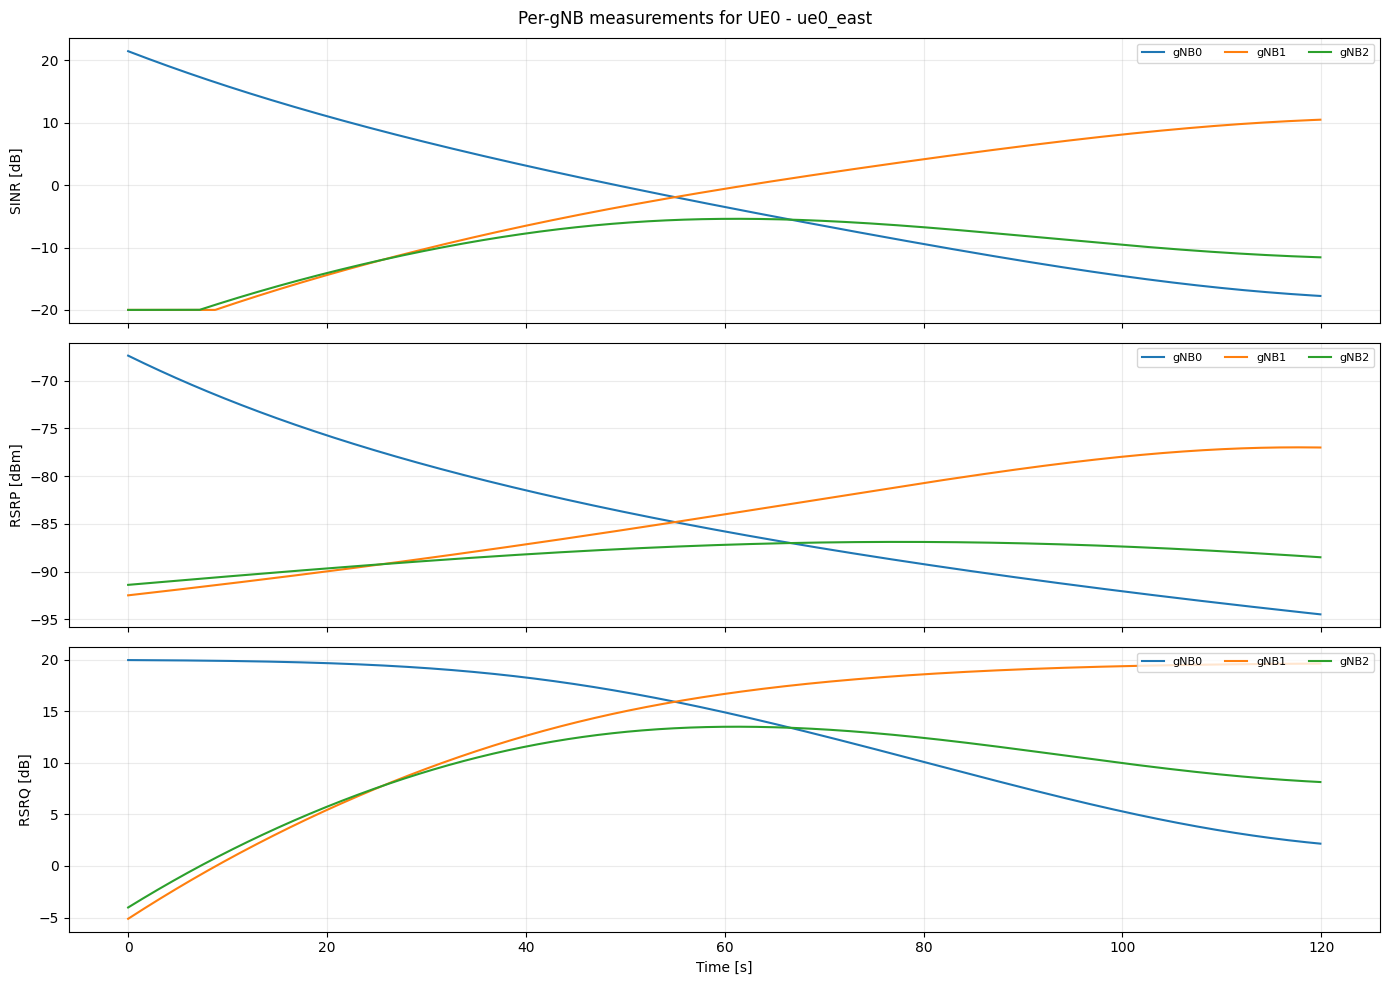

In [13]:
UE_TO_INSPECT = ue_ids[0]
sub = plot_trace[plot_trace["ue_id"] == UE_TO_INSPECT]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for gnb in gnbs:
    axes[0].plot(sub["time_s"], sub[f"g{gnb.id}_sinr_db"], label=f"gNB{gnb.id}")
    axes[1].plot(sub["time_s"], sub[f"g{gnb.id}_rsrp_dbm"], label=f"gNB{gnb.id}")
    axes[2].plot(sub["time_s"], sub[f"g{gnb.id}_rsrq_db"], label=f"gNB{gnb.id}")

axes[0].set_ylabel("SINR [dB]")
axes[1].set_ylabel("RSRP [dBm]")
axes[2].set_ylabel("RSRQ [dB]")
axes[2].set_xlabel("Time [s]")
for ax in axes:
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper right", ncol=3, fontsize=8)
fig.suptitle(f"Per-gNB measurements for UE{UE_TO_INSPECT} - {ue_names[UE_TO_INSPECT]}")
plt.tight_layout()
plt.show()

## Sanity Checks

In [14]:
assert len(trace) == len(ue_ids) * int(np.ceil(N_STEPS / LOG_EVERY)), "unexpected trace length"
assert trace[["sinr_db", "rsrp_dbm", "rsrq_db", "rx_probability", "allocated_prbs", "used_prbs", "wasted_prbs"]].notna().all().all()
assert (trace["used_prbs"] <= trace["allocated_prbs"]).all(), "used_prbs cannot exceed allocated_prbs"
assert (trace["wasted_prbs"] == trace["allocated_prbs"] - trace["used_prbs"]).all(), "wasted_prbs accounting mismatch"
assert trace["ue_id"].nunique() == 5

print("PASS")
print(f"trace saved to: {TRACE_CSV}")
print(f"handover events saved to: {HO_CSV}")
print(f"rows: {len(trace):,}")
print(f"handovers: {len(handover_events)}")

PASS
trace saved to: /home/oussama/Desktop/chech/results/five_ue_3gnb_1min_radio_mobility_trace/five_ue_radio_trace.csv
handover events saved to: /home/oussama/Desktop/chech/results/five_ue_3gnb_1min_radio_mobility_trace/handover_events.csv
rows: 60,000
handovers: 6
